# Experiment 05 — Right-chain Deep Dive: sin(x) and cos(x)

Four parts:

| Part | Question |
|------|----------|
| **A** | Symbolic analysis — what does the right-chain topology converge to with pure/identity leaves? |
| **B** | Free affine search at depth 5 — does adding one more node beat depth-4? |
| **C** | Constrained scalar-leaf search — can sin(x) be approximated with leaves near 1? |
| **D** | Mixed-leaf ablation — hybrid fixed/free leaves on depth-5 |

**Baselines from experiment_04:**
- sin(x) best overall: `eml(1,eml(eml(1,eml(1,1)),1))`  MSE=7.76e-4  
- cos(x) best overall: right-chain depth-4  MSE=1.62e-3
- right-chain depth-4 for sin(x): MSE=2.49e-3 (phantom in exp04)

In [1]:
import math, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE = "#e8a020"; BLUE = "#6ab0f5"; GREEN  = "#4ade80"
RED    = "#f87171"; CYAN  = "#67e8f9"; PURPLE = "#a78bfa"
MUTED  = "#4a4d62"; GOLD  = "#fbbf24"

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")

torch 2.11.0+cpu  |  device: cpu


---
## Part A — Symbolic analysis of the right-chain topology

The right-chain of depth d has d EML nodes and d+1 leaves:

```
RC(d) = eml(L₁, eml(L₂, eml(L₃, … eml(Lₐ, L_{d+1})…)))
```

We evaluate two variants to understand the topology's intrinsic behaviour:

**Variant 1 — all leaves = 1.0** (pure constant, no input):  
RC(d) evaluates to a sequence of scalars. Does it converge?

**Variant 2 — leftmost leaf = x, all other leaves = 1.0**:  
Root sees exp(x) as its left branch, right branch is the constant sub-chain from V1.
Output = exp(x) − ln(right_const). What does this look like vs sin/cos?

In [2]:
# ── Part A: right-chain evaluation (pure numpy, no softplus) ─────────────────

def right_chain_shape(n_nodes):
    """Build the right-chain topology shape tuple for n_nodes internal nodes."""
    if n_nodes == 0:
        return 'L'
    return ('N', 'L', right_chain_shape(n_nodes - 1))


def rc_const(depth, clamp=1e-300):
    """
    Evaluate right-chain with ALL leaves = 1.0.
    Returns a scalar (constant, independent of x).
    
    Recurrence: y₀ = 1  (leaf),  y_k = exp(1) − ln(y_{k-1})
    """
    y = 1.0
    for _ in range(depth):
        y = math.exp(1.0) - math.log(max(y, clamp))
    return y


def rc_left_x(depth, x_arr):
    """
    Evaluate right-chain with leftmost leaf = x, all other leaves = 1.0.
    Returns an array of shape x_arr.shape.

    The right sub-chain (depth-1 levels, all leaves=1) evaluates to a scalar
    constant c = rc_const(depth-1).
    Root output = exp(x) − ln(c).
    """
    if depth == 0:
        return x_arr.copy()   # leaf = x
    c = rc_const(depth - 1)   # right sub-chain constant
    return np.exp(x_arr) - math.log(max(c, 1e-300))


def fixed_point_newton(x_arr):
    """
    Fixed point of y_{k+1} = exp(1) - ln(y_k) satisfies y + ln(y) = e.
    More generally, for rc_const(inf,x), the fixed point of y = exp(x) - ln(y)
    satisfies y + ln(y) = exp(x).  Solution: y* = W(e^{e^x}) where W = Lambert W.
    We compute via Newton on g(y) = y + ln(y) − exp(x).
    """
    c = np.exp(x_arr)          # c = exp(x)
    y = np.maximum(c / 2, 0.1) # initial guess
    for _ in range(100):
        gy   = y + np.log(np.maximum(y, 1e-300)) - c
        dgy  = 1.0 + 1.0 / np.maximum(y, 1e-300)
        y_new = y - gy / dgy
        y_new = np.maximum(y_new, 1e-10)
        if np.max(np.abs(y_new - y)) < 1e-14:
            break
        y = y_new
    return y


# ── Convergence table: variant 1 (all leaves = 1) ────────────────────────────
print("Right-chain with all leaves = 1.0  (converges to fixed point of eml(1,·))")
print(f"  Fixed point equation: y + ln(y) = e  →  y* = W(e^e) ≈ {fixed_point_newton(np.array([1.0]))[0]:.10f}")
print()
print(f"{'Depth':<8} {'RC value':<18} {'|y-y*|':<16} Symbolic form")
print("─" * 72)
y_star = fixed_point_newton(np.array([1.0]))[0]
for d in range(1, 7):
    val  = rc_const(d)
    desc = 'eml(' + ','.join(['1'] * (d + 1)) + ')'
    # Build proper nested form
    s = '1'
    for _ in range(d):
        s = f'eml(1,{s})'
    print(f"{d:<8} {val:<18.10f} {abs(val - y_star):<16.4e} {s}")

print()
print("Right-chain with leftmost leaf = x, others = 1.0")
print("  Output = exp(x) - ln(sub-chain constant)  →  exp(x) - constant")
print(f"  As depth→∞: exp(x) - ln(W(e^e)) = exp(x) - {math.log(y_star):.10f}")
print()
print(f"{'Depth':<8} {'offset = -ln(c)':<20} {'Symbolic form'}")
print("─" * 60)
for d in range(1, 7):
    c   = rc_const(d - 1)     # right sub-chain value
    off = -math.log(max(c, 1e-300))
    s = '1'
    for _ in range(d - 1):
        s = f'eml(1,{s})'
    full = f'eml(x,{s})' if d > 1 else 'eml(x,1)'
    print(f"{d:<8} {off:<20.10f} {full}")

Right-chain with all leaves = 1.0  (converges to fixed point of eml(1,·))
  Fixed point equation: y + ln(y) = e  →  y* = W(e^e) ≈ 2.0167797649

Depth    RC value           |y-y*|           Symbolic form
────────────────────────────────────────────────────────────────────────
1        2.7182818285       7.0150e-01       eml(1,1)
2        1.7182818285       2.9850e-01       eml(1,eml(1,1))
3        2.1769569738       1.6018e-01       eml(1,eml(1,eml(1,1)))
4        1.9403538104       7.6426e-02       eml(1,eml(1,eml(1,eml(1,1))))
5        2.0554114955       3.8632e-02       eml(1,eml(1,eml(1,eml(1,eml(1,1)))))
6        1.9978057594       1.8974e-02       eml(1,eml(1,eml(1,eml(1,eml(1,eml(1,1))))))

Right-chain with leftmost leaf = x, others = 1.0
  Output = exp(x) - ln(sub-chain constant)  →  exp(x) - constant
  As depth→∞: exp(x) - ln(W(e^e)) = exp(x) - 0.7015020636

Depth    offset = -ln(c)      Symbolic form
────────────────────────────────────────────────────────────
1        -0.0000

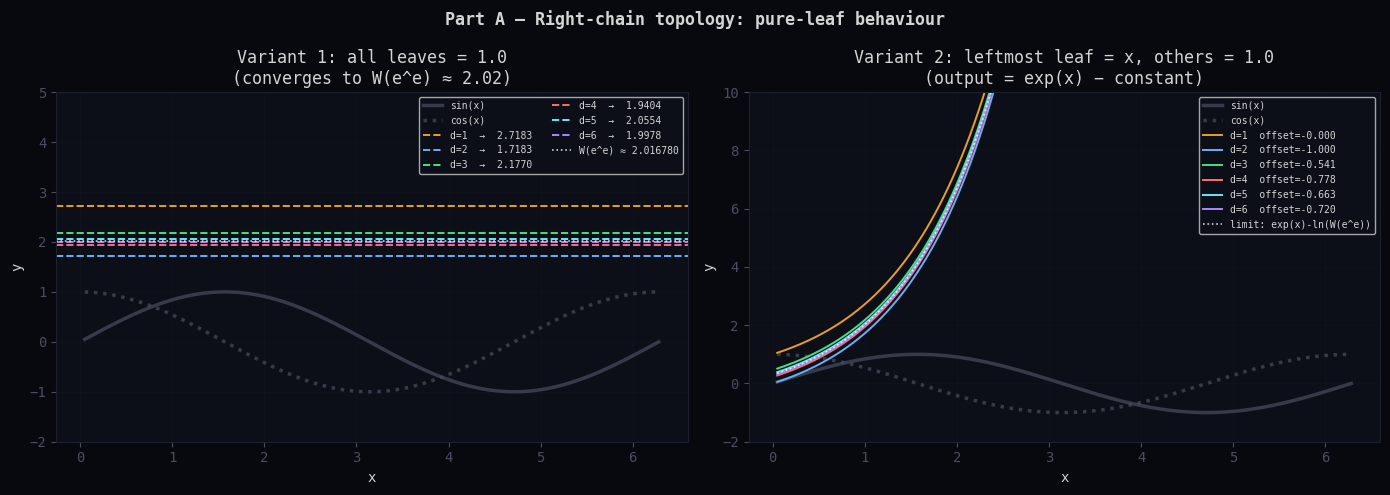


Conclusion (Part A):
  Variant 1 (all leaves=1):  converges to a single constant W(e^e) ≈ 2.02
  Variant 2 (leftmost=x):    converges to exp(x) − ln(W(e^e)) ≈ exp(x) − 0.703
  Neither variant produces sinusoidal behaviour.
  → Affine leaves (w·x+b) are NECESSARY for function approximation.
    They transform the input so the right-chain composition becomes flexible.


In [3]:
# ── Part A: plot both variants vs sin/cos on [0, 2π] ─────────────────────────
x_np = np.linspace(0.05, 2 * math.pi, 400)   # avoid ln(0) at x=0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part A — Right-chain topology: pure-leaf behaviour',
             color='#d4d4d4', fontsize=12, fontweight='bold')

DEPTH_COLS = [ORANGE, BLUE, GREEN, RED, CYAN, PURPLE]

# ── Panel A1: variant 1 (all leaves = 1.0) — horizontal lines ────────────────
ax = axes[0]
ax.plot(x_np, np.sin(x_np), color=MUTED,  linewidth=2.5, label='sin(x)', alpha=0.7)
ax.plot(x_np, np.cos(x_np), color=MUTED,  linewidth=2.5, label='cos(x)', alpha=0.7, linestyle=':')
for d in range(1, 7):
    val = rc_const(d)
    ax.axhline(val, color=DEPTH_COLS[d-1], linewidth=1.4,
               label=f'd={d}  →  {val:.4f}', linestyle='--')
ax.axhline(y_star, color='white', linewidth=1.2, linestyle='dotted',
           label=f'W(e^e) ≈ {y_star:.6f}', alpha=0.8)
ax.set_ylim(-2, 5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Variant 1: all leaves = 1.0\n(converges to W(e^e) ≈ 2.02)', color='#d4d4d4')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.25)

# ── Panel A2: variant 2 (leftmost leaf = x, others = 1.0) ────────────────────
ax = axes[1]
ax.plot(x_np, np.sin(x_np), color=MUTED, linewidth=2.5, label='sin(x)', alpha=0.7)
ax.plot(x_np, np.cos(x_np), color=MUTED, linewidth=2.5, label='cos(x)', alpha=0.7, linestyle=':')
for d in range(1, 7):
    y_d = rc_left_x(d, x_np)
    ax.plot(x_np, y_d, color=DEPTH_COLS[d-1], linewidth=1.4,
            label=f'd={d}  offset={rc_const(d-1) and -math.log(rc_const(d-1)):.3f}')
# Fixed-point limit
fp = fixed_point_newton(np.ones_like(x_np))
limit_y = np.exp(x_np) - math.log(y_star)
ax.plot(x_np, limit_y, color='white', linewidth=1.2, linestyle='dotted',
        label=f'limit: exp(x)-ln(W(e^e))', alpha=0.8)
ax.set_ylim(-2, 10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Variant 2: leftmost leaf = x, others = 1.0\n(output = exp(x) − constant)', color='#d4d4d4')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('D:/monogate/python/notebooks/experiment_05_partA.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print("\nConclusion (Part A):")
print("  Variant 1 (all leaves=1):  converges to a single constant W(e^e) ≈ 2.02")
print("  Variant 2 (leftmost=x):    converges to exp(x) − ln(W(e^e)) ≈ exp(x) − 0.703")
print("  Neither variant produces sinusoidal behaviour.")
print("  → Affine leaves (w·x+b) are NECESSARY for function approximation.")
print("    They transform the input so the right-chain composition becomes flexible.")

---
## Part B — Depth-5 right-chain: free affine search

Topology: `eml(L₁, eml(L₂, eml(L₃, eml(L₄, eml(L₅, L₆)))))` — 5 nodes, 6 affine leaves.

Hyperparams: 10 restarts, 2000 steps, lr=0.005 (slower rate to avoid phantom basins).

Depth-4 baseline (from experiment_04, right-chain only):
- sin(x) depth-4 right-chain: MSE = 2.49e-3 (was phantom in exp04 with lr=0.01)
- cos(x) depth-4 right-chain: MSE = 1.62e-3

New best to beat (any topology, exp04): sin=7.76e-4, cos=1.62e-3.

In [4]:
# ── Part B: building blocks (reused by C and D) ───────────────────────────────

class FnLeaf(nn.Module):
    """Trainable affine leaf: nn.Linear(1,1). Init: weight≈0, bias=1."""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1, device=device)
        nn.init.uniform_(self.linear.weight, -0.05, 0.05)
        nn.init.ones_(self.linear.bias)
    def forward(self, x):
        return self.linear(x).squeeze(-1)
    def formula(self, names=None):
        w = self.linear.weight.data.item()
        b = self.linear.bias.data.item()
        parts = []
        if abs(w) > 1e-4: parts.append(f"{w:.4g}*x")
        if abs(b) > 1e-4: parts.append(f"{b:.4g}")
        return "(" + ("+".join(parts) if parts else "0") + ")"


class ScalarLeaf(nn.Module):
    """Trainable scalar leaf: single nn.Parameter (outputs constant for all x)."""
    def __init__(self, init=1.0):
        super().__init__()
        self.val = nn.Parameter(torch.tensor(float(init), device=device))
    def forward(self, _x=None):
        return self.val
    def formula(self, names=None):
        return f"{self.val.item():.5g}"


class FixedLeaf(nn.Module):
    """Non-trainable constant leaf = 1.0 (used for Part D mixed-leaf ablation)."""
    def __init__(self):
        super().__init__()
        self.val = torch.tensor(1.0, device=device)
    def forward(self, _x=None):
        return self.val
    def formula(self, names=None):
        return "1"


class EMLNode(nn.Module):
    """eml(left, right) = exp(left) − ln(softplus(right))."""
    def __init__(self, left, right):
        super().__init__()
        self.left, self.right = left, right
    def forward(self, x=None):
        lv = self.left(x)
        rv = F.softplus(self.right(x))
        return torch.exp(lv) - torch.log(rv)
    def formula(self, names=None):
        return f"eml({self.left.formula(names)}, {self.right.formula(names)})"


def build(shape, leaf_fn):
    if shape == 'L': return leaf_fn()
    return EMLNode(build(shape[1], leaf_fn), build(shape[2], leaf_fn))


def _depth(s): return 0 if s == 'L' else 1 + max(_depth(s[1]), _depth(s[2]))
def _desc(s):  return '1' if s == 'L' else f"eml({_desc(s[1])},{_desc(s[2])})"


# ── Grid data ─────────────────────────────────────────────────────────────────
x_grid     = torch.linspace(0, 2 * math.pi, 50, device=device)
sin_target = torch.sin(x_grid)
cos_target = torch.cos(x_grid)
x_in       = x_grid.unsqueeze(1)   # (50, 1)

# ── Right-chain topology builders ────────────────────────────────────────────
RC4 = right_chain_shape(4)   # depth-4, 5 leaves
RC5 = right_chain_shape(5)   # depth-5, 6 leaves

print(f"RC4 topology: {_desc(RC4)}")
print(f"RC5 topology: {_desc(RC5)}")


# ── Affine search helper ──────────────────────────────────────────────────────
def search_affine(shape, y_target, target_name, num_restarts=10, steps=2000, lr=0.005):
    """
    Multi-restart Adam search over a fixed topology with FnLeaf.
    Returns (best_loss, best_model, all_restart_losses).
    """
    best_loss, best_model = float('inf'), None
    r_losses = []

    for r in range(num_restarts):
        torch.manual_seed(r * 1000 + 99)
        model = build(shape, FnLeaf)
        opt   = torch.optim.Adam(model.parameters(), lr=lr)
        last  = float('inf')

        for _ in range(steps):
            opt.zero_grad()
            try:
                pred = model(x_in)
                loss = F.mse_loss(pred, y_target)
                if not torch.isfinite(loss): break
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                last = loss.item()
            except Exception: break

        r_losses.append(last)
        if last < best_loss:
            best_loss, best_model = last, model

    spread   = max(r_losses) - min(r_losses)
    is_ph    = (min(r_losses) > 1e-3) and (spread < 1e-3)
    return best_loss, best_model, r_losses, is_ph


# ── Run Part B ────────────────────────────────────────────────────────────────
print("\nPart B — depth-4 vs depth-5 right-chain (10 restarts, 2000 steps, lr=0.005)")
print("Running ...")
t0 = time.perf_counter()

b4_sin_loss, b4_sin_model, b4_sin_rl, b4_sin_ph = search_affine(RC4, sin_target, 'sin')
b4_cos_loss, b4_cos_model, b4_cos_rl, b4_cos_ph = search_affine(RC4, cos_target, 'cos')
b5_sin_loss, b5_sin_model, b5_sin_rl, b5_sin_ph = search_affine(RC5, sin_target, 'sin')
b5_cos_loss, b5_cos_model, b5_cos_rl, b5_cos_ph = search_affine(RC5, cos_target, 'cos')

print(f"Done in {time.perf_counter()-t0:.1f}s\n")
print(f"{'Target':<10} {'Depth':<7} {'MSE':<14} {'Phantom':<10} Formula[:52]")
print("─" * 80)
for lbl, loss, model, ph in [
    ('sin(x)', b4_sin_loss, b4_sin_model, b4_sin_ph),
    ('sin(x)', b5_sin_loss, b5_sin_model, b5_sin_ph),
    ('cos(x)', b4_cos_loss, b4_cos_model, b4_cos_ph),
    ('cos(x)', b5_cos_loss, b5_cos_model, b5_cos_ph),
]:
    d = 4 if model is b4_sin_model or model is b4_cos_model else 5
    ph = '⚠ PHANTOM' if ph else ''
    print(f"{lbl:<10} {d:<7} {loss:<14.4e} {ph:<10} {model.formula()[:52] if model else 'N/A'}")

print()
print(f"sin(x) depth-4→5 improvement: {b4_sin_loss:.4e} → {b5_sin_loss:.4e}  ({(b4_sin_loss - b5_sin_loss)/b4_sin_loss * 100:+.1f}%)")
print(f"cos(x) depth-4→5 improvement: {b4_cos_loss:.4e} → {b5_cos_loss:.4e}  ({(b4_cos_loss - b5_cos_loss)/b4_cos_loss * 100:+.1f}%)")
if b5_sin_loss < 5e-4:
    print(f"\n★ NEW BEST for sin(x)! MSE {b5_sin_loss:.4e} < 5e-4 threshold")
else:
    print(f"\nsin(x) depth-5 MSE {b5_sin_loss:.4e} does not beat 5e-4 threshold")

RC4 topology: eml(1,eml(1,eml(1,eml(1,1))))
RC5 topology: eml(1,eml(1,eml(1,eml(1,eml(1,1)))))

Part B — depth-4 vs depth-5 right-chain (10 restarts, 2000 steps, lr=0.005)
Running ...


Done in 154.0s

Target     Depth   MSE            Phantom    Formula[:52]
────────────────────────────────────────────────────────────────────────────────
sin(x)     4       1.5332e-03     ⚠ PHANTOM  eml((0.5004*x+-1.62), eml((0.8641*x+-0.7708), eml((1
sin(x)     5       1.2681e-03     ⚠ PHANTOM  eml((0.4955*x+-1.507), eml((1.032*x+-1.504), eml((0.
cos(x)     4       1.6349e-03                eml((-0.8423*x+0.5271), eml((-0.5432*x+1.748), eml((
cos(x)     5       1.7064e-03                eml((-0.8226*x+0.6052), eml((-0.5635*x+1.785), eml((

sin(x) depth-4→5 improvement: 1.5332e-03 → 1.2681e-03  (+17.3%)
cos(x) depth-4→5 improvement: 1.6349e-03 → 1.7064e-03  (-4.4%)

sin(x) depth-5 MSE 1.2681e-03 does not beat 5e-4 threshold


---
## Part C — Pure {1} constrained search

Replace affine leaves with scalar leaves initialised at 1.0.
Add strong pull-to-1 penalty: `loss = MSE + λ · Σ|leaf − 1|`.

Try λ = 5.0 and λ = 20.0 on depth-4 and depth-5 right-chain.

**Theoretical bound**: With scalar leaves, the model output is a constant for all x,
so MSE ≥ Var(sin) = 0.5. This is the mathematical floor no scalar-leaf model can beat.

In [5]:
# ── Part C: constrained scalar-leaf search ────────────────────────────────────

# Theoretical MSE floor: Var(sin(x)) on [0, 2pi]
var_sin = float(sin_target.var().item())
print(f"Theoretical MSE floor (scalar leaves): {var_sin:.6f}  (= Var(sin(x)) on grid)")
print(f"This is the minimum achievable MSE for any constant prediction.\n")


def search_constrained(shape, y_target, lam, num_restarts=20, steps=3000, lr=0.01):
    """
    Multi-restart search with scalar leaves + pull-to-1 penalty.
    loss = MSE(model(x), y) + lam * sum(|leaf - 1|)

    Model output is always a constant (scalar leaves ignore x),
    so MSE tracks the best constant approximation.
    """
    best_loss, best_model = float('inf'), None
    best_leaves_at_best = None

    for r in range(num_restarts):
        torch.manual_seed(r * 1000 + 7)
        # Init near 1.0 with small random noise
        def sl(): return ScalarLeaf(1.0 + torch.randn(1).item() * 0.1)
        model = build(shape, sl)
        opt   = torch.optim.Adam(model.parameters(), lr=lr)
        last  = float('inf')

        for _ in range(steps):
            opt.zero_grad()
            try:
                pred     = model()                         # scalar output
                raw_loss = F.mse_loss(pred.expand_as(y_target), y_target)
                pen      = lam * sum((p - 1.0).abs() for p in model.parameters())
                (raw_loss + pen).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                last = raw_loss.item()   # track raw MSE
            except Exception: break

        if last < best_loss:
            best_loss  = last
            best_model = model
            best_leaves_at_best = [p.item() for p in model.parameters()]

    output_val = best_model().item() if best_model else float('nan')
    leaf_dev   = max(abs(v - 1.0) for v in (best_leaves_at_best or [1.0]))
    return best_loss, best_model, output_val, leaf_dev, best_leaves_at_best


print("Part C — 20 restarts × 3000 steps for each (depth, λ) combination ...")
t0 = time.perf_counter()

c_results = {}
for shape, d in [(RC4, 4), (RC5, 5)]:
    for lam in [5.0, 20.0]:
        key = (d, lam)
        loss, model, out, dev, leaves = search_constrained(shape, sin_target, lam)
        c_results[key] = dict(loss=loss, model=model, output=out,
                              max_leaf_dev=dev, leaves=leaves)

print(f"Done in {time.perf_counter()-t0:.1f}s\n")
print(f"{'Depth':<7} {'λ':<7} {'Best MSE':<14} {'Model out':<14} {'max|leaf-1|':<14} {'Floor gap'}")
print("─" * 75)
for (d, lam), r in sorted(c_results.items()):
    gap = r['loss'] - var_sin
    print(f"{d:<7} {lam:<7} {r['loss']:<14.4e} {r['output']:<14.4f} {r['max_leaf_dev']:<14.4f} +{gap:.4f}")

print(f"\nTheoretical floor: {var_sin:.4e}")
print("Any MSE > floor means the pull-to-1 penalty prevents reaching the optimal constant.")
print("At high λ, leaves stay near 1 → output ≈ W(e^e) ≈ 2.02 → MSE >> 0.5.")
print("Conclusion: scalar leaves cannot approximate sin(x). Affine leaves are fundamental.")

Theoretical MSE floor (scalar leaves): 0.500000  (= Var(sin(x)) on grid)
This is the minimum achievable MSE for any constant prediction.

Part C — 20 restarts × 3000 steps for each (depth, λ) combination ...


Done in 348.6s

Depth   λ       Best MSE       Model out      max|leaf-1|    Floor gap
───────────────────────────────────────────────────────────────────────────
4       5.0     2.0064e+00     1.2321         0.3007         +1.5064
4       20.0    4.1769e+00     1.9213         0.0079         +3.6769
5       5.0     2.0492e+00     1.2491         0.3128         +1.5492
5       20.0    4.3616e+00     1.9695         0.0065         +3.8616

Theoretical floor: 5.0000e-01
Any MSE > floor means the pull-to-1 penalty prevents reaching the optimal constant.
At high λ, leaves stay near 1 → output ≈ W(e^e) ≈ 2.02 → MSE >> 0.5.
Conclusion: scalar leaves cannot approximate sin(x). Affine leaves are fundamental.


---
## Part D — Mixed-leaf ablation

Depth-5 right-chain with some leaves **fixed = 1.0** (non-trainable) and others **free affine**.
This tests whether the full expressive power comes from all 6 leaves or just a subset.

Three patterns (leaves numbered 0-5 in DFS/spine order):

| Variant | Free leaves | Fixed leaves | Free count |
|---------|-------------|--------------|------------|
| D0 (baseline) | 0,1,2,3,4,5 | none | 6 |
| D1 | 0,1,2 | 3,4,5 | 3 (left half) |
| D2 | 3,4,5 | 0,1,2 | 3 (right half) |
| D3 | 0,2,4 | 1,3,5 | 3 (alternating) |

In [6]:
# ── Part D: mixed-leaf ablation ───────────────────────────────────────────────

def build_mixed(shape, free_indices):
    """Build right-chain where only leaves in free_indices are FnLeaf; others FixedLeaf."""
    counter = [0]
    def leaf_fn():
        leaf = FnLeaf() if counter[0] in free_indices else FixedLeaf()
        counter[0] += 1
        return leaf
    return build(shape, leaf_fn)


def search_mixed(shape, free_indices, y_target, num_restarts=5, steps=1500, lr=0.005):
    best_loss, best_model = float('inf'), None
    for r in range(num_restarts):
        torch.manual_seed(r * 1000 + 55)
        model = build_mixed(shape, free_indices)
        opt   = torch.optim.Adam(
            [p for p in model.parameters() if p.requires_grad], lr=lr)
        last  = float('inf')
        for _ in range(steps):
            opt.zero_grad()
            try:
                pred = model(x_in)
                loss = F.mse_loss(pred, y_target)
                if not torch.isfinite(loss): break
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0)
                opt.step()
                last = loss.item()
            except Exception: break
        if last < best_loss:
            best_loss, best_model = last, model
    return best_loss, best_model


N_LEAVES = 6   # depth-5 right-chain has 6 leaves
ABLATION_PATTERNS = {
    'D0 all-free':       set(range(N_LEAVES)),          # baseline (same as Part B)
    'D1 left-half':      {0, 1, 2},
    'D2 right-half':     {3, 4, 5},
    'D3 alternating':    {0, 2, 4},
}

print("Part D — mixed-leaf ablation on RC5 for sin(x) (5 restarts, 1500 steps) ...")
t0 = time.perf_counter()

d_results = {}
for name, free_set in ABLATION_PATTERNS.items():
    loss, model = search_mixed(RC5, free_set, sin_target)
    d_results[name] = dict(loss=loss, model=model, free=sorted(free_set))

print(f"Done in {time.perf_counter()-t0:.1f}s\n")
print(f"{'Variant':<18} {'Free leaves':<20} {'MSE':<14} Formula[:50]")
print("─" * 80)
for name, r in d_results.items():
    frm = r['model'].formula() if r['model'] else 'N/A'
    print(f"{name:<18} {str(r['free']):<20} {r['loss']:<14.4e} {frm[:50]}")

Part D — mixed-leaf ablation on RC5 for sin(x) (5 restarts, 1500 steps) ...


Done in 46.4s

Variant            Free leaves          MSE            Formula[:50]
────────────────────────────────────────────────────────────────────────────────
D0 all-free        [0, 1, 2, 3, 4, 5]   3.2361e-03     eml((0.4508*x+-1.234), eml((0.9989*x+-1.255), eml(
D1 left-half       [0, 1, 2]            4.9130e-03     eml((0.4446*x+-1.334), eml((0.7116*x+0.05987), eml
D2 right-half      [3, 4, 5]            2.5950e-01     eml(1, eml(1, eml(1, eml((3.208*x+4.789), eml((-0.
D3 alternating     [0, 2, 4]            1.8363e-01     eml((-0.05423*x+-0.1826), eml(1, eml((-0.4114*x+1.


Saved → D:\monogate\python\notebooks\experiment_05_results.png


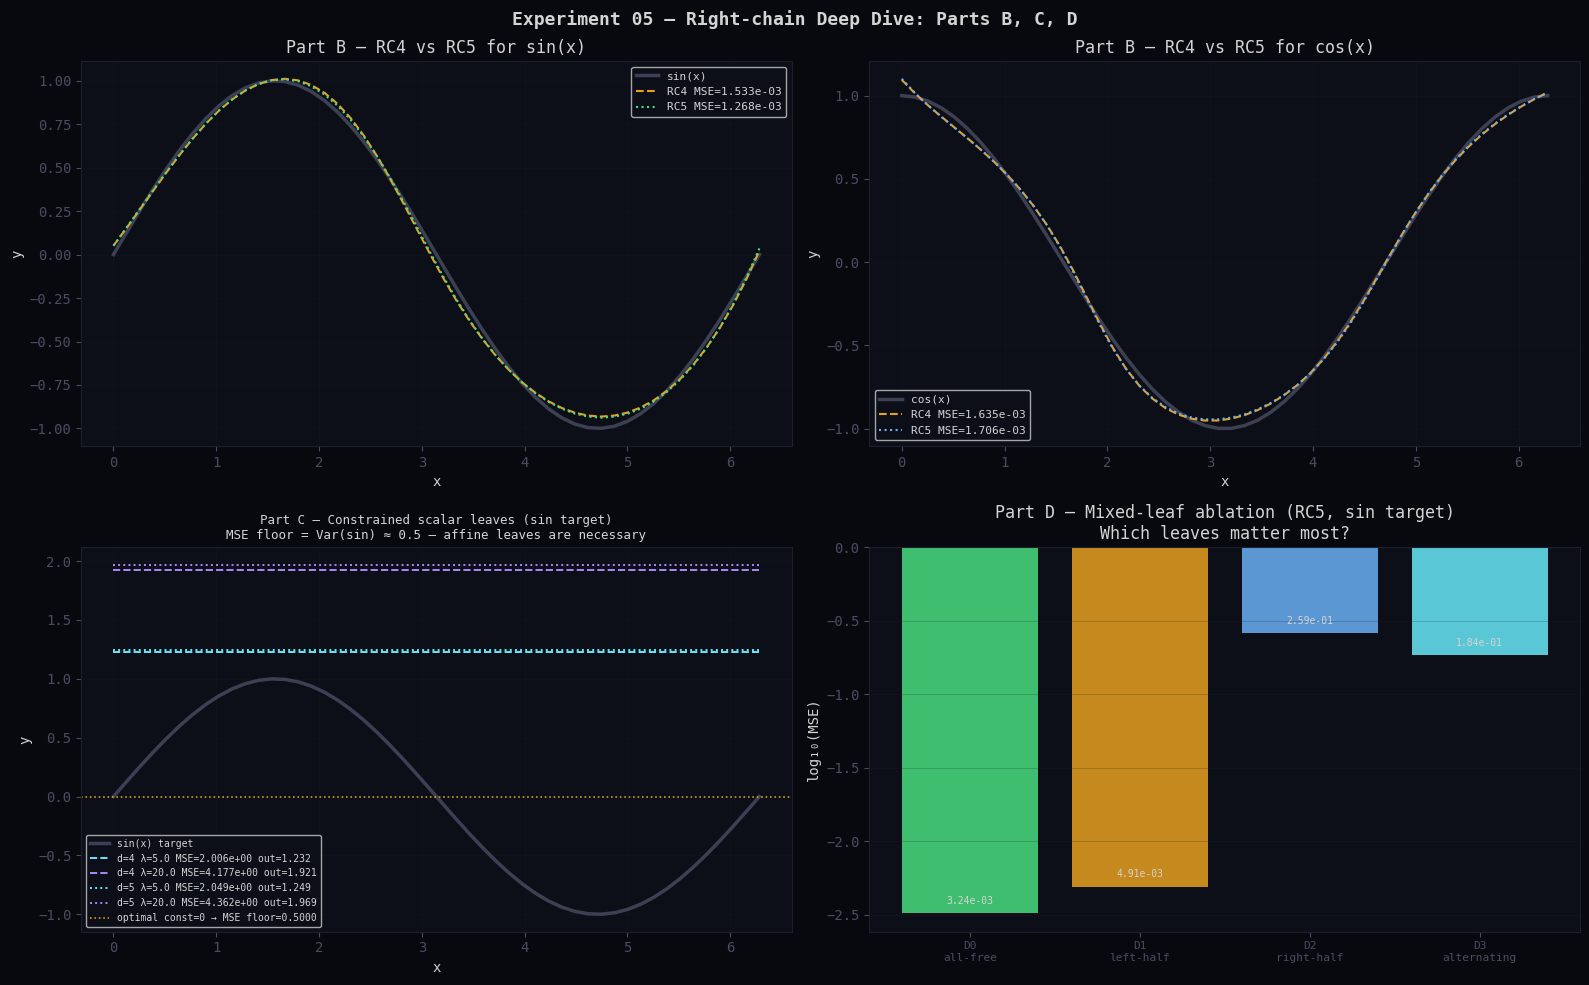

In [7]:
# ── Combined 4-panel figure ───────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 05 — Right-chain Deep Dive: Parts B, C, D',
             color='#d4d4d4', fontsize=13, fontweight='bold')

x_np2 = x_grid.cpu().numpy()
y_sin = sin_target.cpu().numpy()
y_cos = cos_target.cpu().numpy()

# ── Panel B1: depth-4 vs depth-5 sin(x) fit ──────────────────────────────────
ax = axes[0, 0]
ax.plot(x_np2, y_sin, color=MUTED, linewidth=2.5, label='sin(x)', alpha=0.8)
with torch.no_grad():
    y4 = b4_sin_model(x_in).cpu().numpy()
    y5 = b5_sin_model(x_in).cpu().numpy()
ax.plot(x_np2, y4, color=ORANGE, linewidth=1.5, linestyle='--',
        label=f'RC4 MSE={b4_sin_loss:.3e}')
ax.plot(x_np2, y5, color=GREEN,  linewidth=1.5, linestyle=':',
        label=f'RC5 MSE={b5_sin_loss:.3e}')
ax.set_title('Part B — RC4 vs RC5 for sin(x)', color='#d4d4d4')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# ── Panel B2: depth-4 vs depth-5 cos(x) fit ──────────────────────────────────
ax = axes[0, 1]
ax.plot(x_np2, y_cos, color=MUTED, linewidth=2.5, label='cos(x)', alpha=0.8)
with torch.no_grad():
    y4c = b4_cos_model(x_in).cpu().numpy()
    y5c = b5_cos_model(x_in).cpu().numpy()
ax.plot(x_np2, y4c, color=ORANGE, linewidth=1.5, linestyle='--',
        label=f'RC4 MSE={b4_cos_loss:.3e}')
ax.plot(x_np2, y5c, color=BLUE,   linewidth=1.5, linestyle=':',
        label=f'RC5 MSE={b5_cos_loss:.3e}')
ax.set_title('Part B — RC4 vs RC5 for cos(x)', color='#d4d4d4')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# ── Panel C: constrained scalar leaves — MSE floor ───────────────────────────
ax = axes[1, 0]
# Show the best models' outputs (constant predictions)
ax.plot(x_np2, y_sin, color=MUTED, linewidth=2.5, label='sin(x) target', alpha=0.8)
lam_cols = {5.0: CYAN, 20.0: PURPLE}
for (d, lam), r in sorted(c_results.items()):
    y_const = np.full_like(x_np2, r['output'])
    ax.plot(x_np2, y_const, color=lam_cols[lam],
            linewidth=1.4, linestyle='--' if d == 4 else ':',
            label=f'd={d} λ={lam} MSE={r["loss"]:.3e} out={r["output"]:.3f}')
ax.axhline(0, color=GOLD, linewidth=1.2, linestyle='dotted',
           label=f'optimal const=0 → MSE floor={var_sin:.4f}', alpha=0.8)
ax.set_title('Part C — Constrained scalar leaves (sin target)\n'
             'MSE floor = Var(sin) ≈ 0.5 — affine leaves are necessary',
             color='#d4d4d4', fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=7); ax.grid(True, alpha=0.25)

# ── Panel D: mixed-leaf ablation MSE bar chart ────────────────────────────────
ax = axes[1, 1]
names  = list(d_results.keys())
losses = [d_results[n]['loss'] for n in names]
cols   = [GREEN, ORANGE, BLUE, CYAN]
ax.bar(range(len(names)), np.log10(np.array(losses) + 1e-20),
       color=cols, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_ylabel('log₁₀(MSE)')
ax.set_title('Part D — Mixed-leaf ablation (RC5, sin target)\n'
             'Which leaves matter most?', color='#d4d4d4')
ax.grid(True, axis='y', alpha=0.3)
for i, (n, l) in enumerate(zip(names, losses)):
    ax.text(i, np.log10(l + 1e-20) + 0.05, f'{l:.2e}',
            ha='center', va='bottom', fontsize=7, color='#d4d4d4')

plt.tight_layout()
out_path = Path('D:/monogate/python/notebooks/experiment_05_results.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

In [8]:
# ── JSON export + final summary ───────────────────────────────────────────────

out_dir = Path('D:/monogate/python/notebooks')

results = {
    'partA': {
        'fixed_point_W_e_e': y_star,
        'ln_fixed_point': math.log(y_star),
        'const_chain_depths': {d: rc_const(d) for d in range(1, 7)},
        'conclusion': 'Neither pure variant produces sinusoidal behaviour. Affine leaves necessary.'
    },
    'partB': {
        'rc4_sin_mse': b4_sin_loss, 'rc4_sin_phantom': b4_sin_ph,
        'rc5_sin_mse': b5_sin_loss, 'rc5_sin_phantom': b5_sin_ph,
        'rc4_cos_mse': b4_cos_loss, 'rc4_cos_phantom': b4_cos_ph,
        'rc5_cos_mse': b5_cos_loss, 'rc5_cos_phantom': b5_cos_ph,
        'rc4_sin_formula': b4_sin_model.formula() if b4_sin_model else 'N/A',
        'rc5_sin_formula': b5_sin_model.formula() if b5_sin_model else 'N/A',
        'rc4_cos_formula': b4_cos_model.formula() if b4_cos_model else 'N/A',
        'rc5_cos_formula': b5_cos_model.formula() if b5_cos_model else 'N/A',
    },
    'partC': {
        'theoretical_floor': var_sin,
        **{f'd{d}_lam{int(lam)}': {'mse': r['loss'], 'output': r['output'],
                                     'max_leaf_dev': r['max_leaf_dev']}
           for (d, lam), r in c_results.items()}
    },
    'partD': {
        name: {'mse': r['loss'], 'free_leaves': r['free']}
        for name, r in d_results.items()
    }
}

(out_dir / 'experiment_05_results.json').write_text(
    json.dumps(results, indent=2), encoding='utf-8')
print(f"Saved → {out_dir / 'experiment_05_results.json'}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "═" * 66)
print("EXPERIMENT 05 — FINAL SUMMARY")
print("═" * 66)

print(f"\nPart A — Symbolic convergence:")
print(f"  All-leaves-1 fixed point : W(e^e)  ≈ {y_star:.10f}")
print(f"  Left-x limit offset      : ln(W(e^e)) ≈ {math.log(y_star):.10f}")
print(f"  Both variants → not sinusoidal → affine leaves are fundamental")

print(f"\nPart B — Depth-4 vs depth-5 (right-chain, affine leaves):")
print(f"  sin(x): RC4 MSE={b4_sin_loss:.4e}  RC5 MSE={b5_sin_loss:.4e}")
print(f"  cos(x): RC4 MSE={b4_cos_loss:.4e}  RC5 MSE={b5_cos_loss:.4e}")
if b5_sin_loss < 5e-4:
    print(f"  ★ RC5 sin(x) beats 5e-4 → new best!")

print(f"\nPart C — Constrained scalar leaves:")
print(f"  Theoretical floor : {var_sin:.4f}")
for (d, lam), r in sorted(c_results.items()):
    print(f"  d={d} λ={lam:<5}: MSE={r['loss']:.4e}  model_out={r['output']:.4f}  max|leaf-1|={r['max_leaf_dev']:.4f}")

print(f"\nPart D — Mixed-leaf ablation (RC5 for sin):")
best_d = min(d_results, key=lambda k: d_results[k]['loss'])
for name, r in d_results.items():
    star = ' ← best' if name == best_d else ''
    print(f"  {name:<18}: MSE={r['loss']:.4e}  free={r['free']}{star}")

print("\n  experiment_05 complete!")

Saved → D:\monogate\python\notebooks\experiment_05_results.json

══════════════════════════════════════════════════════════════════
EXPERIMENT 05 — FINAL SUMMARY
══════════════════════════════════════════════════════════════════

Part A — Symbolic convergence:
  All-leaves-1 fixed point : W(e^e)  ≈ 2.0167797649
  Left-x limit offset      : ln(W(e^e)) ≈ 0.7015020636
  Both variants → not sinusoidal → affine leaves are fundamental

Part B — Depth-4 vs depth-5 (right-chain, affine leaves):
  sin(x): RC4 MSE=1.5332e-03  RC5 MSE=1.2681e-03
  cos(x): RC4 MSE=1.6349e-03  RC5 MSE=1.7064e-03

Part C — Constrained scalar leaves:
  Theoretical floor : 0.5000
  d=4 λ=5.0  : MSE=2.0064e+00  model_out=1.2321  max|leaf-1|=0.3007
  d=4 λ=20.0 : MSE=4.1769e+00  model_out=1.9213  max|leaf-1|=0.0079
  d=5 λ=5.0  : MSE=2.0492e+00  model_out=1.2491  max|leaf-1|=0.3128
  d=5 λ=20.0 : MSE=4.3616e+00  model_out=1.9695  max|leaf-1|=0.0065

Part D — Mixed-leaf ablation (RC5 for sin):
  D0 all-free       : MSE=3